# Model Evaluation
Evaluate forecasting model performance and generate insights.

In [1]:
# Load predictions and actuals
# Calculate performance metrics
# Generate evaluation report


import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv(
    '../data/processed/clean_cargo_trends.csv',
    parse_dates=['Record_Date'])

# Aggregate monthly
monthly = (df.groupby(
    df['Record_Date'].dt.to_period('M'))
    ['Total_Volume_MMT'].sum()
    .reset_index())
monthly.columns = ['ds', 'y']
monthly['ds'] = monthly[
    'ds'].dt.to_timestamp()
monthly = monthly[
    monthly['ds'] < '2026-06-01']

# Train/test split — last 6 months = test
split_date = '2025-06-01'
train = monthly[monthly['ds'] < split_date]
test  = monthly[monthly['ds'] >= split_date]

print(f"Train: {len(train)} months")
print(f"Test:  {len(test)} months")
print(f"Train ends: {train['ds'].max().date()}")
print(f"Test starts: {test['ds'].min().date()}")

c:\Users\offic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Train: 24 months
Test:  12 months
Train ends: 2025-05-01
Test starts: 2025-06-01


In [2]:
# Train model on training data only
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05)

model.fit(train)

# Create future dataframe covering
# test period
future = model.make_future_dataframe(
    periods=len(test),
    freq='MS')

forecast = model.predict(future)

# Extract predictions for test period
test_forecast = forecast[
    forecast['ds'] >= split_date][
    ['ds','yhat','yhat_lower',
     'yhat_upper']].copy()

# Merge with actual test values
evaluation = test.merge(
    test_forecast, on='ds')
evaluation.columns = [
    'Month', 'Actual',
    'Predicted', 'Lower', 'Upper']
evaluation = evaluation.round(3)

print("=== Actual vs Predicted ===")
display(evaluation)

21:42:07 - cmdstanpy - INFO - Chain [1] start processing
21:42:18 - cmdstanpy - INFO - Chain [1] done processing


=== Actual vs Predicted ===


,Month,Actual,Predicted,Lower,Upper
0,2025-06-01,11.201,10.780,10.775,10.784
1,2025-07-01,10.848,11.601,11.587,11.617
2,2025-08-01,11.641,11.362,11.334,11.392
3,2025-09-01,13.306,14.203,14.148,14.260
4,2025-10-01,18.164,18.199,18.100,18.303
5,2025-11-01,18.009,16.656,16.537,16.786
6,2025-12-01,18.698,18.976,18.798,19.158
7,2026-01-01,14.760,14.517,14.351,14.682
8,2026-02-01,14.239,13.956,13.759,14.145
9,2026-03-01,14.068,14.916,14.666,15.149


In [3]:
actual    = evaluation['Actual'].values
predicted = evaluation['Predicted'].values

mae  = mean_absolute_error(actual, predicted)
mape = np.mean(
    np.abs((actual - predicted)
           / actual)) * 100
rmse = np.sqrt(
    np.mean((actual - predicted) ** 2))

# Within-range accuracy
in_range = (
    (evaluation['Actual'] >=
     evaluation['Lower']) &
    (evaluation['Actual'] <=
     evaluation['Upper'])
).sum()
range_pct = (in_range / len(evaluation)
             * 100)

print("=" * 35)
print("    MODEL EVALUATION RESULTS")
print("=" * 35)
print(f"MAE:        {mae:.3f} MMT")
print(f"MAPE:       {mape:.2f}%")
print(f"RMSE:       {rmse:.3f} MMT")
print(f"In CI band: {in_range}/"
      f"{len(evaluation)} months "
      f"({range_pct:.1f}%)")
print("=" * 35)

if mape < 10:
    print("Rating: EXCELLENT ")
elif mape < 15:
    print("Rating: GOOD ")
elif mape < 25:
    print("Rating: ACCEPTABLE ")
else:
    print("Rating: NEEDS IMPROVEMENT ")

    MODEL EVALUATION RESULTS
MAE:        0.554 MMT
MAPE:       3.92%
RMSE:       0.675 MMT
In CI band: 2/12 months (16.7%)
Rating: EXCELLENT 


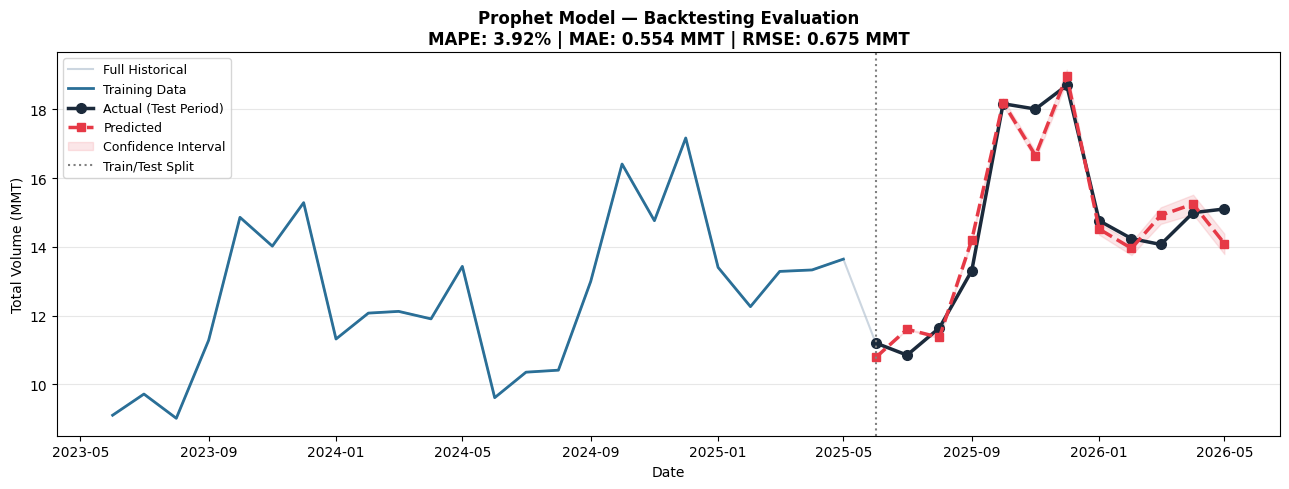

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

# Full historical context
ax.plot(monthly['ds'], monthly['y'],
        color='#AABBCC', linewidth=1.5,
        label='Full Historical',
        alpha=0.6)

# Training data
ax.plot(train['ds'], train['y'],
        color='#2A6F97', linewidth=2,
        label='Training Data')

# Actual test values
ax.plot(evaluation['Month'],
        evaluation['Actual'],
        color='#1B2A3B', linewidth=2.5,
        marker='o', markersize=7,
        label='Actual (Test Period)')

# Predicted values
ax.plot(evaluation['Month'],
        evaluation['Predicted'],
        color='#E63946', linewidth=2.5,
        linestyle='--', marker='s',
        markersize=6,
        label='Predicted')

# Confidence band
ax.fill_between(
    evaluation['Month'],
    evaluation['Lower'],
    evaluation['Upper'],
    color='#E63946', alpha=0.12,
    label='Confidence Interval')

# Split line
ax.axvline(
    pd.to_datetime(split_date),
    color='grey', linestyle=':',
    linewidth=1.5,
    label='Train/Test Split')

ax.set_title(
    f'Prophet Model — Backtesting '
    f'Evaluation\n'
    f'MAPE: {mape:.2f}% | '
    f'MAE: {mae:.3f} MMT | '
    f'RMSE: {rmse:.3f} MMT',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Volume (MMT)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../assets/model_evaluation.png',
    dpi=150, bbox_inches='tight')
plt.show()

In [5]:
evaluation['Error'] = (
    evaluation['Actual'] -
    evaluation['Predicted']).round(3)
evaluation['Error_Pct'] = (
    (evaluation['Error'] /
     evaluation['Actual'])
    * 100).round(2)

print("=== Month-by-Month Error ===")
display(evaluation[[
    'Month', 'Actual',
    'Predicted', 'Error',
    'Error_Pct']])

print(f"\nBest prediction: "
      f"{evaluation['Error_Pct'].abs().min():.2f}%")
print(f"Worst prediction: "
      f"{evaluation['Error_Pct'].abs().max():.2f}%")

# Save evaluation results
evaluation.to_csv(
    '../data/processed/'
    'model_evaluation.csv',
    index=False)
print("\nSaved to "
      "data/processed/model_evaluation.csv")

=== Month-by-Month Error ===


,Month,Actual,Predicted,Error,Error_Pct
0,2025-06-01,11.201,10.780,0.421,3.76
1,2025-07-01,10.848,11.601,-0.753,-6.94
2,2025-08-01,11.641,11.362,0.279,2.40
3,2025-09-01,13.306,14.203,-0.897,-6.74
4,2025-10-01,18.164,18.199,-0.035,-0.19
5,2025-11-01,18.009,16.656,1.353,7.51
6,2025-12-01,18.698,18.976,-0.278,-1.49
7,2026-01-01,14.760,14.517,0.243,1.65
8,2026-02-01,14.239,13.956,0.283,1.99
9,2026-03-01,14.068,14.916,-0.848,-6.03



Best prediction: 0.19%
Worst prediction: 7.51%

Saved to data/processed/model_evaluation.csv
